# SmartCart Day 2 - Localize

Day 1 gave us labelled single-product photos. A checkout sees a **counter full of items**, but GroceryStoreDataset does **not** provide bounding boxes. Today we create box labels by compositing real product photos into multi-item scenes, fine-tune **YOLO11** to find products, and crop the detections back out for Day 3's recognizer.

In [1]:
# 1) Runtime setup
# This course runs in Google Colab. Run this cell first.
# Install only the packages used in this notebook.
%pip install -q ultralytics

import os

# Drive stores the small cross-day bundle, not the image dataset.
from google.colab import drive
drive.mount('/content/drive')
BUNDLE_DIR = '/content/drive/MyDrive/snaic/week_4/Project/SmartCart'



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.8 MB/s eta 0:00:00
Mounted at /content/drive


### Embedded toolkit

This hidden cell defines the helper functions used below. It is embedded so the notebook needs no separate `.py` upload. Run it once after setup.

In [2]:
from __future__ import annotations
import json
import os
import pathlib
import subprocess
import numpy as np
import pandas as pd
HERE = pathlib.Path.cwd()  # embedded in-notebook: no __file__, anchor on the working dir
GROCERY_DATASET_URL = 'https://github.com/marcusklasson/GroceryStoreDataset'

class Bundle:
    """Small Google Drive folder that carries artifacts from one day to the next."""

    def __init__(self, root: str):
        self.root = pathlib.Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.manifest = {'version': 1, 'class_list': [], 'artifacts': {}}

    def put_table(self, name, df: pd.DataFrame):
        df.to_csv(self.root / name, index=False)
        self._note(name)

    def get_table(self, name) -> pd.DataFrame:
        return pd.read_csv(self.root / name)

    def put_array(self, name, arr: np.ndarray):
        np.save(self.root / name, arr)
        self._note(name)

    def get_array(self, name) -> np.ndarray:
        p = self.root / name
        return np.load(p if p.suffix == '.npy' else p.with_suffix('.npy'))

    def _note(self, name):
        self.manifest['artifacts'][name] = True

    def save(self):
        (self.root / 'manifest.json').write_text(json.dumps(self.manifest, indent=2))

    def load(self):
        p = self.root / 'manifest.json'
        if p.exists():
            self.manifest = json.loads(p.read_text())
        return self

def open_bundle(drive_dir='/content/drive/MyDrive/SmartCart') -> Bundle:
    """Open the cross-day Drive bundle. If it is new, start with an empty manifest."""
    return Bundle(drive_dir).load()

def save_bundle(b: Bundle):
    b.save()
    print(f'[bundle] saved -> {b.root}')

def open_grocery_dataset():
    """Clone or reuse the real GroceryStoreDataset and return (tier, root_dir)."""
    root = HERE / 'GroceryStoreDataset'
    if (root / 'dataset' / 'classes.csv').exists():
        print('using cached GroceryStoreDataset:', root)
    else:
        print('cloning GroceryStoreDataset from:', GROCERY_DATASET_URL)
        subprocess.run(['git', 'clone', '--depth', '1', GROCERY_DATASET_URL, str(root)], check=True)
    if not (root / 'dataset' / 'classes.csv').exists():
        raise RuntimeError('GroceryStoreDataset clone is incomplete. Check Colab network access and rerun.')
    print('using data tier: github')
    print('data root:', root)
    print('OK: using real GroceryStoreDataset images.')
    return ('github', str(root))

def list_images(root, per_class=None):
    """Return a DataFrame with columns path,coarse,fine from GroceryStoreDataset train/val/test folders."""
    root = pathlib.Path(root)
    rows = []
    for split in ('train', 'val', 'test'):
        for p in (root / 'dataset' / split).rglob('*.jpg'):
            rows.append({'path': str(p), 'coarse': p.parent.parent.name, 'fine': p.parent.name})
    df = pd.DataFrame(rows)
    if per_class and len(df):
        df = df.groupby('fine', group_keys=False).head(per_class).reset_index(drop=True)
    return df

def compose_scene(crops, canvas=(640, 640), seed=0, max_items=None):
    """Paste crops onto a blank canvas. Paste coordinates become detection boxes."""
    rng = np.random.default_rng(seed)
    H, W = canvas
    tint = rng.integers(225, 250, size=(1, 1, 3), dtype=np.uint8)
    noise = rng.integers(0, 12, size=(H, W, 3), dtype=np.uint8)
    img = np.minimum(tint + noise, 255).astype(np.uint8)
    boxes = []

    def iou_xywh(a, b):
        ax, ay, aw, ah = a
        bx, by, bw, bh = b
        ix1, iy1 = (max(ax, bx), max(ay, by))
        ix2, iy2 = (min(ax + aw, bx + bw), min(ay + ah, by + bh))
        inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
        union = aw * ah + bw * bh - inter
        return inter / union if union else 0.0
    for crop, label in crops if max_items is None else crops[:max_items]:
        ch, cw = crop.shape[:2]
        if ch >= H or cw >= W:
            continue
        x, y = (0, 0)
        for _ in range(40):
            x = int(rng.integers(0, W - cw))
            y = int(rng.integers(0, H - ch))
            if all((iou_xywh((x, y, cw, ch), b[:4]) < 0.08 for b in boxes)):
                break
        img[y:y + ch, x:x + cw] = crop
        boxes.append((x, y, cw, ch, label))
    return (img, boxes)

def yolo_boxes_to_txt(boxes, canvas, class_to_id):
    """Convert (x,y,w,h,label) pixel boxes to YOLO txt lines."""
    H, W = canvas
    lines = []
    for x, y, w, h, label in boxes:
        lines.append(f'{class_to_id[label]} {(x + w / 2) / W:.6f} {(y + h / 2) / H:.6f} {w / W:.6f} {h / H:.6f}')
    return '\n'.join(lines)
# --- helpers are now available as plain functions/classes in this notebook ---
print('SmartCart toolkit ready')


SmartCart toolkit ready


In [3]:
# 2) Load the cross-day bundle
# The bundle stores artifacts we create during the week: labels, indexes, weights, ONNX files.
# It is NOT the image dataset. Images are loaded in the next data-source cell.
b = open_bundle(BUNDLE_DIR)
print('bundle:', b.root)
print('artifacts:', list(b.manifest.get('artifacts', {})))


bundle: /content/drive/MyDrive/snaic/week_4/Project/SmartCart
artifacts: ['gallery_index.npy', 'gallery_meta.csv', 'catalog_prices.csv', 'labels.csv', 'sample_scene.jpg', 'detector.pt', 'crops_manifest.csv', 'head.pt', 'per_class_metrics.csv', 'error_report.md']


In [4]:
# 3) Select the image data source
# For class runs we require the real GroceryStoreDataset. If GitHub is unavailable, stop clearly.
tier, root = open_grocery_dataset()


cloning GroceryStoreDataset from: https://github.com/marcusklasson/GroceryStoreDataset
using data tier: github
data root: /content/GroceryStoreDataset
OK: using real GroceryStoreDataset images.


## List product images (this runtime)

**What:** Re-list the product images from the data tier - paths must be valid in *today's* runtime.

**Why:** Each day is a fresh Colab VM, so we re-derive images rather than trust absolute paths saved on another day.

**Watch for:** Confirm the previous cell printed `using data tier: github` before continuing.

In [5]:
# Re-list images in this runtime. Do not reuse yesterday's absolute paths.
per_class = int(os.environ.get('SC_PER_CLASS','40'))
df = list_images(root, per_class=per_class)
assert len(df) > 0, 'No GroceryStoreDataset images found. Re-run the data-source cell.'
print(len(df), 'images across', df.fine.nunique(), 'classes')


3232 images across 81 classes


## Compose multi-item counter scenes

**What:** Paste product photos from GroceryStoreDataset onto 640x640 canvases and emit YOLO label files.

**Why:** The dataset has class labels but no boxes. Because we control where each product is pasted, we know each bounding box exactly.

**Watch for:** We use a SINGLE class id 0 = 'product' (class-agnostic localization). Recognition is Day 3's job — keep detection simple and honest.

In [6]:
import os, glob
import numpy as np
from PIL import Image
# Step 1: class-agnostic detection. Every SKU maps to one id: product.
class_to_id = {fine: 0 for fine in df.fine.unique()}
# Step 2: collect image paths by SKU for balanced scene sampling.
by_class = {f: g.path.tolist() for f, g in df.groupby('fine')}
rng = np.random.default_rng(0)
# Step 3: create the YOLO folder layout.
for split in ['train','val']:
    os.makedirs(f'datasets/scenes/images/{split}', exist_ok=True)
    os.makedirs(f'datasets/scenes/labels/{split}', exist_ok=True)
# Step 4: compose scenes. The paste location gives us the YOLO bounding box label.
scene_map = {}  # scene_id -> list of (x,y,w,h,fine)
n_scenes = int(os.environ.get('SC_SCENES', 80))
for i in range(n_scenes):
    split = 'val' if i % 4 == 0 else 'train'
    picks = []
    # Mix single-item and multi-item scenes; this helps Day 5 uploads of one product.
    n_items = 1 if i % 5 == 0 else int(rng.integers(2, 6))
    for fine in rng.choice(list(by_class), size=n_items, replace=True):
        p = rng.choice(by_class[fine])
        size = int(rng.integers(90, 261))
        crop = np.array(Image.open(p).convert('RGB').resize((size, size)))
        picks.append((crop, fine))
    img, boxes = compose_scene(picks, canvas=(640,640), seed=i)
    Image.fromarray(img).save(f'datasets/scenes/images/{split}/scene_{i:03d}.jpg')
    open(f'datasets/scenes/labels/{split}/scene_{i:03d}.txt','w').write(
        yolo_boxes_to_txt(boxes, (640,640), class_to_id))
    scene_map[i] = (split, boxes)
with open('datasets/scenes/data.yaml','w') as f:
    f.write('path: datasets/scenes\ntrain: images/train\nval: images/val\nnames:\n  0: product\n')
print('composed', len(scene_map), 'scenes with varied item counts and sizes')


composed 80 scenes with varied item counts and sizes


## Visualize ground-truth boxes

**What:** Draw the boxes that the notebook generated from paste coordinates.

**Why:** Students should see why these labels are valid: the notebook knows exactly where each product was pasted.

**Watch for:** Green boxes are ground truth. If boxes overlap heavily, the composed scene is a weak training example.

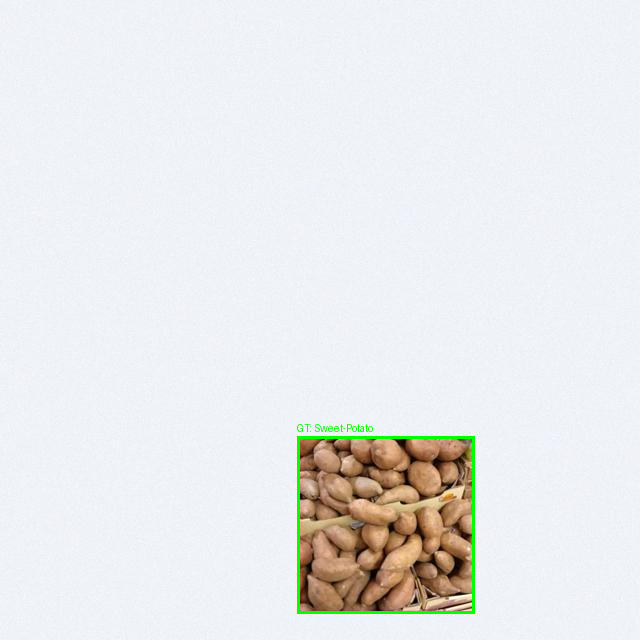

In [7]:
from PIL import ImageDraw
def draw_xywh_boxes(image_path, boxes, color='lime', label_prefix='GT'):
    im = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(im)
    for x, y, w, h, label in boxes:
        draw.rectangle([x, y, x+w, y+h], outline=color, width=3)
        draw.text((x, max(0, y-14)), f'{label_prefix}: {label}', fill=color)
    return im
gt_img = draw_xywh_boxes('datasets/scenes/images/val/scene_000.jpg', scene_map[0][1])
gt_img


## Optional: annotate real scenes

**What:** Use Label Studio or a similar tool if your team wants to replace composed scenes with manually boxed real counter/cart photos.

**Why:** Manual annotation is slower, but it tests whether the detector improves when trained on realistic clutter, lighting, and occlusion.

**Watch for:** Keep the same YOLO format: one `product` box per visible item. Compare manual-data YOLO against the composed-scene baseline.

In [ ]:
print('Optional extension, not required for the core lab:')
print('1. Capture real counter/cart photos with multiple grocery items.')
print('2. Annotate visible product boxes in Label Studio as a single class: product.')
print('3. Export YOLO labels and arrange them as images/train, images/val, labels/train, labels/val.')
print('4. Train YOLO on those real annotations and compare mAP + Day 5 demo quality.')


Optional extension, not required for the core lab:
1. Capture real counter/cart photos with multiple grocery items.
2. Annotate visible product boxes in Label Studio as a single class: product.
3. Export YOLO labels and arrange them as images/train, images/val, labels/train, labels/val.
4. Train YOLO on those real annotations and compare mAP + Day 5 demo quality.


## Baseline YOLO11

**What:** Run an out-of-the-box COCO-pretrained YOLO11n on one composed scene.

**Why:** Shows why we must fine-tune: COCO has 'banana' but not 'Granny-Smith' or 'Yoghurt'.

**Watch for:** Detections will be sparse/mislabelled - that's the point, it has never seen our products.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
baseline COCO detections: 0 — wrong class space for our products


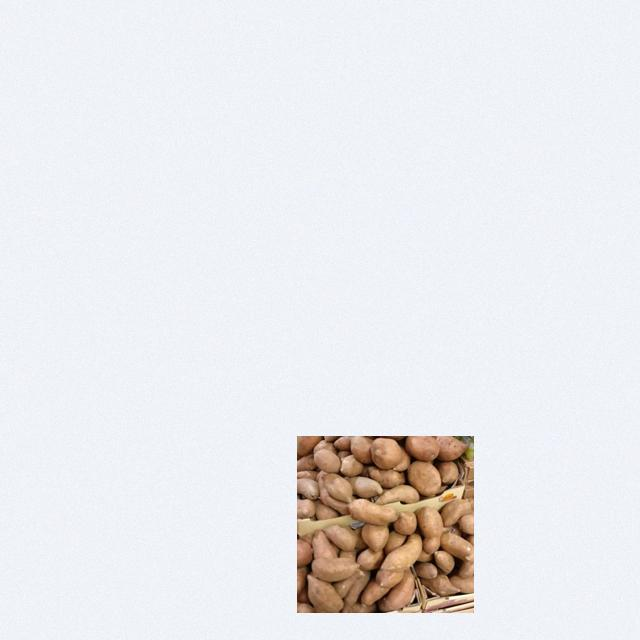

In [8]:
from ultralytics import YOLO
m = YOLO('yolo11n.pt')
r0 = m('datasets/scenes/images/val/scene_000.jpg', verbose=False)[0]
print('baseline COCO detections:', len(r0.boxes), '— wrong class space for our products')
baseline_img = Image.open('datasets/scenes/images/val/scene_000.jpg').convert('RGB')
draw = ImageDraw.Draw(baseline_img)
for box, cls_id, conf in zip(r0.boxes.xyxy.cpu().numpy(), r0.boxes.cls.cpu().numpy(), r0.boxes.conf.cpu().numpy()):
    x1,y1,x2,y2 = [int(v) for v in box]
    label = f'{r0.names.get(int(cls_id), str(int(cls_id)))} {conf:.2f}'
    draw.rectangle([x1,y1,x2,y2], outline='red', width=3)
    draw.text((x1, max(0,y1-14)), label, fill='red')
baseline_img


## Fine-tune YOLO11 (core)

**What:** Train YOLO11 on our class-agnostic product scenes.

**Why:** A few epochs teach it 'this blob is a product' regardless of COCO's vocabulary.

**Watch for:** CPU users get fewer epochs (SC_EPOCHS); Colab GPU gets 20. mAP will be modest on generated data.

In [9]:
epochs = int(os.environ.get('SC_EPOCHS', 20))
res = m.train(data='datasets/scenes/data.yaml', epochs=epochs, imgsz=640, verbose=False)
try:
    print('fine-tuned mAP50-95:', float(res.box.map))
except Exception:
    print('training finished; see runs/ for metrics')
detector_path = os.path.join(getattr(res, 'save_dir', 'runs/detect/train'), 'weights', 'best.pt')
detector = YOLO(detector_path)
print('loaded fine-tuned detector:', detector_path)


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/scenes/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pe

## Baseline vs fine-tuned

**What:** Compare the COCO baseline against the fine-tuned detector on the same scene.

**Why:** Qualitatively the fine-tuned model should box products tightly with the single 'product' class.

**Watch for:** If fine-tuned boxes look worse, you likely need more epochs or more composed scenes.

fine-tuned detections on scene_000: 1
baseline had 0 -> fine-tuned has 1


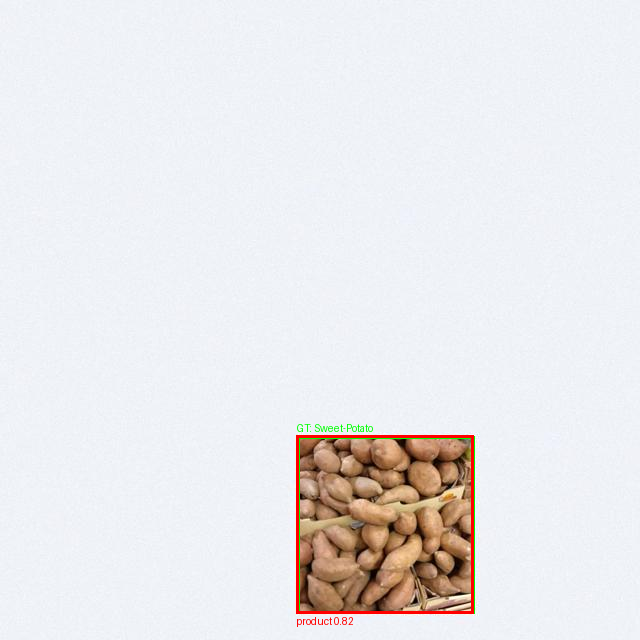

In [10]:
rb = detector('datasets/scenes/images/val/scene_000.jpg', verbose=False)[0]
print('fine-tuned detections on scene_000:', len(rb.boxes))
print('baseline had', len(r0.boxes), '-> fine-tuned has', len(rb.boxes))
compare = draw_xywh_boxes('datasets/scenes/images/val/scene_000.jpg', scene_map[0][1], color='lime', label_prefix='GT')
draw = ImageDraw.Draw(compare)
for box, cls_id, conf in zip(rb.boxes.xyxy.cpu().numpy(), rb.boxes.cls.cpu().numpy(), rb.boxes.conf.cpu().numpy()):
    x1,y1,x2,y2 = [int(v) for v in box]
    label = f'{rb.names.get(int(cls_id), str(int(cls_id)))} {conf:.2f}'
    draw.rectangle([x1,y1,x2,y2], outline='red', width=3)
    draw.text((x1, min(compare.height-16, y2+2)), label, fill='red')
compare


## Explain a detection with Grad-CAM

**What:** Run true Grad-CAM on the fine-tuned YOLO11 detector to see which pixels drove its "a product is here" decision on one scene.

**Why:** YOLO11 is a genuine CNN (unlike Day 3's DINOv2 recognizer, which is a ViT and can't use Grad-CAM natively) - this is the one place in the pipeline where Grad-CAM applies with no adaptation needed. This explains *detection* ("why did it box something here?"), which is a different question from Day 3's occlusion sensitivity, which explains *recognition* ("why did it call this a Granny Smith apple?"). Both are needed; neither replaces the other.

**Watch for:** `target_layer` below assumes a typical YOLO11 layer layout. If it errors or the heatmap looks meaningless, run `print(detector.model.model)` to see the real layer list and adjust the index.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 85.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


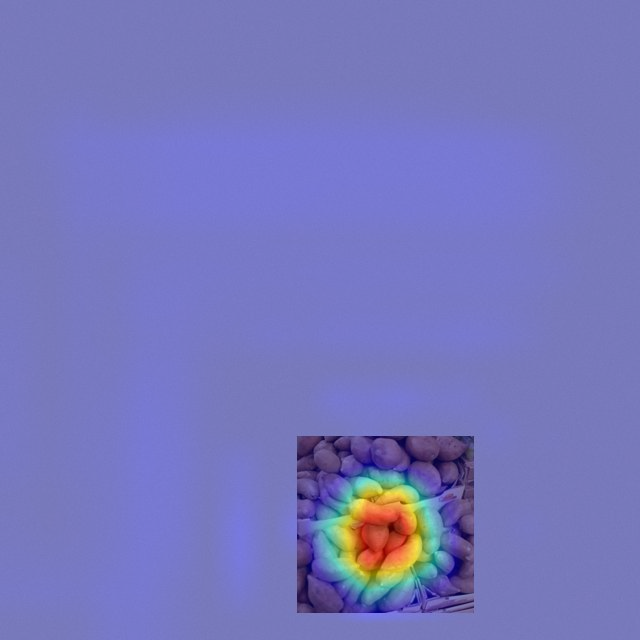

In [11]:
%pip install -q grad-cam

import numpy as np
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

class YOLOBoxScoreTarget:
    """Grad-CAM target: the highest class-confidence score anywhere in the raw YOLO
    head output. With a single 'product' class, this is just 'how strongly did the
    detector believe a product exists here' - exactly what we want to explain."""
    def __call__(self, output):
        preds = output[0] if isinstance(output, (list, tuple)) else output
        # Ultralytics raw head output is (batch, 4 + num_classes, num_anchors).
        # Drop the 4 box-coordinate channels, keep only class-confidence channels.
        cls_scores = preds[:, 4:, ...] if preds.dim() == 3 else preds[4:]
        return cls_scores.reshape(-1).max()

def yolo_gradcam(detector, img_path, img_size=640, target_layer=None):
    """Grad-CAM heatmap for a fine-tuned YOLO detector. This is native, unmodified
    Grad-CAM - no ViT-style reshaping or artifact-token caveats needed, because the
    detector backbone is a real CNN."""
    model = detector.model.eval()

    # Ultralytics caches anchor/stride buffers on the Detect head the first time it sees
    # a given input shape. Earlier cells called detector(...) via Ultralytics' predict()
    # path, which runs under torch.inference_mode() - so those cached tensors are
    # permanently off-limits to autograd. Since our Grad-CAM call uses the same 640x640
    # shape, the head would otherwise reuse those poisoned tensors instead of recomputing
    # fresh ones. Forcing dynamic=True makes it always recompute in our own (grad-enabled)
    # forward pass instead.
    detect_head = model.model[-1]
    detect_head.dynamic = True

    if target_layer is None:
        # Last conv-ish block before the detection head.
        # If this looks wrong: print(model.model) and pick a different index.
        target_layer = model.model[-2]

    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    rgb = np.asarray(img).astype(np.float32) / 255.0
    input_tensor = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0).float()
    input_tensor.requires_grad_(True)  # needed: Ultralytics loads inference models with
                                        # requires_grad=False on all params, so without this
                                        # nothing in the graph has a grad_fn for CAM to use.

    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor, targets=[YOLOBoxScoreTarget()])[0]
    overlay = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)
    return Image.fromarray(overlay), grayscale_cam

overlay_img, heatmap = yolo_gradcam(detector, 'datasets/scenes/images/val/scene_000.jpg')
overlay_img

## Crop ROIs

**What:** Run the fine-tuned detector on every scene, crop each box, and recover its fine label.

**Why:** Day 3 trains a recognizer on real-shaped crops (detector output), not just clean catalog photos.

**Watch for:** Labels are recovered by matching detected boxes to the composed boxes we stashed in scene_map.

In [12]:
import shutil
import pandas as pd
from pathlib import Path
def iou(a, b):
    ax,ay,aw,ah = a; bx,by,bw,bh = b
    ix1,iy1 = max(ax,bx), max(ay,by); ix2,iy2 = min(ax+aw,bx+bw), min(ay+ah,by+bh)
    iw,ih = max(0,ix2-ix1), max(0,iy2-iy1); inter = iw*ih
    union = aw*ah + bw*bh - inter
    return inter/union if union else 0.0
bundle_crops = Path(b.root) / 'crops'
bundle_crops.mkdir(parents=True, exist_ok=True)
rows = []
for i,(split, gboxes) in scene_map.items():
    img = np.array(Image.open(f'datasets/scenes/images/{split}/scene_{i:03d}.jpg').convert('RGB'))
    det = detector(f'datasets/scenes/images/{split}/scene_{i:03d}.jpg', verbose=False)[0]
    for j, box in enumerate(det.boxes.xyxy.cpu().numpy()):
        x1,y1,x2,y2 = [int(v) for v in box]; dw,dh = x2-x1, y2-y1
        if dw < 5 or dh < 5: continue
        best_gt = max(gboxes, key=lambda gb: iou((x1,y1,dw,dh),(gb[0],gb[1],gb[2],gb[3])), default=None)
        if best_gt is None: continue
        fine = best_gt[4]
        cp = bundle_crops / f'scene{i:03d}_{j}.jpg'
        Image.fromarray(img[y1:y2, x1:x2]).save(cp)
        rows.append({'crop_path': str(cp), 'fine': fine})
crops_df = pd.DataFrame(rows)
sample_scene = Path(b.root) / 'sample_scene.jpg'
shutil.copy('datasets/scenes/images/val/scene_000.jpg', sample_scene); b._note('sample_scene.jpg')
# Copy the best fine-tuned weights into the bundle as detector.pt for Day 5.
shutil.copy(detector_path, os.path.join(b.root, 'detector.pt')); b._note('detector.pt')
print('crops:', len(crops_df), '| detector.pt and sample_scene.jpg copied into bundle')


crops: 211 | detector.pt and sample_scene.jpg copied into bundle


## Save + carry forward

**What:** Persist the crops manifest and save the bundle.

**Why:** Day 3 reads `crops_manifest.csv`; Day 5 uses `sample_scene.jpg` for a fresh-runtime demo.

**Watch for:** Confirm detector.pt and sample_scene.jpg show up in the bundle artifacts.

In [13]:
b.put_table('crops_manifest.csv', crops_df)
save_bundle(b)
print('\u25b6 Carries forward to Day 3/5: detector.pt + crops_manifest.csv + sample_scene.jpg')


[bundle] saved -> /content/drive/MyDrive/snaic/week_4/Project/SmartCart
▶ Carries forward to Day 3/5: detector.pt + crops_manifest.csv + sample_scene.jpg
